## Linear Regression Analysis: Advertising Dataset

### 1. Project Objective

The main objectives of the project are:

* to analyze the advertising dataset,
* to examine the relationship between TV advertising expenditure and sales,
* to build a simple linear regression model with one independent variable,
* to verify the assumptions of linear regression,
* to build a multiple linear regression model,
* to compare the developed models.

### 2. Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import pingouin as pg

from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

### 3. Loading and Basic Data Analysis

In [32]:
url = "https://www.statlearning.com/s/Advertising.csv"

advertising = pd.read_csv(url, index_col=0)

advertising.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [33]:
advertising.shape

(200, 4)

In [34]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [35]:
advertising.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [36]:
advertising.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [37]:
advertising.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


#### Comment:

The dataset contains information on advertising expenditure in TV, radio, and newspapers, along with the corresponding sales. The data contain no missing observations. In the subsequent analysis, sales will be used as the dependent variable.

## 4. Linear Regression

In [38]:
Y= advertising['sales']
X = sm.add_constant(advertising['TV'])


model = sm.OLS(Y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.47e-42
Time:                        07:29:00   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 5. Regression Plot

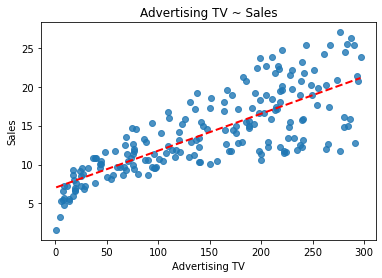

In [39]:
x = advertising['TV'].to_numpy()
y = advertising['sales'].to_numpy()

x_grid = np.linspace(x.min(), x.max(), 200)
y_hat = results.params['const'] + results.params['TV'] * x_grid

plt.scatter(x,y, alpha = 0.8)
plt.plot(x_grid, y_hat, linewidth = 2, color="red", linestyle="--")
plt.xlabel('Advertising TV')
plt.ylabel('Sales')
plt.title('Advertising TV ~ Sales')
plt.show()

#### Comment:

The plot indicates a positive, approximately linear relationship between TV advertising expenditure and sales. The data points are distributed around the regression line, suggesting that the linearity assumption can be considered satisfied.

### 6.Regression Assumptions

#### a. Linearity was presented in the plot above.

#### b. Homoscedasticity.

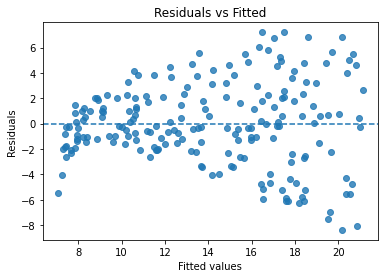

In [40]:
fitted = results.fittedvalues
resid = results.resid

plt.scatter(fitted, resid, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#### Comment:

The assumption of homoscedasticity is probably not satisfied. For higher fitted values, the model tends to produce larger residuals, indicating that the variance of the residuals may increase with the predicted values.

### 7. Normality of Residuals

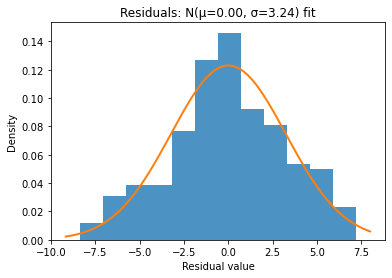

In [41]:
mu, sigma = stats.norm.fit(resid)

plt.hist(resid, bins=12, density=True, alpha=0.8)
xmin, xmax = plt.xlim()
x_line = np.linspace(xmin, xmax, 200)
plt.plot(x_line, stats.norm.pdf(x_line, mu, sigma), linewidth=2)

plt.title(f"Residuals: N(μ={mu:.2f}, σ={sigma:.2f}) fit")
plt.xlabel("Residual value")
plt.ylabel("Density")
plt.show()

#### Comment:

The histogram of the residuals has a shape that is close to a normal distribution. Small deviations from perfect normality can be observed in the tails of the distribution; however, overall, the assumption of normally distributed residuals can be considered satisfied.

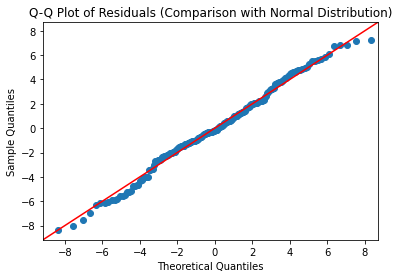

Shapiro-Wilk test: stat=0.991, p-value=0.2133


In [42]:
qqplot(resid, loc=mu, scale=sigma, line="45")
plt.title("Q-Q Plot of Residuals (Comparison with Normal Distribution)")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk test: stat={shapiro_stat:.3f}, p-value={shapiro_p:.4f}")

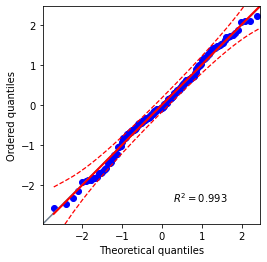

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
pg.qqplot(results.resid, dist='norm', confidence=0.95)
plt.show()

#### Comment:

The Q-Q plot shows that the points lie almost entirely along the reference line, indicating that the distribution of the residuals is close to normal. Small deviations can be observed only in the extreme parts of the distribution (the tails); however, they are not large enough to question the assumption of normality. The R² = 0.993 indicates a very close fit of the observed points to the theoretical line.

### 8. Independence of Residuals

1.93468853728236


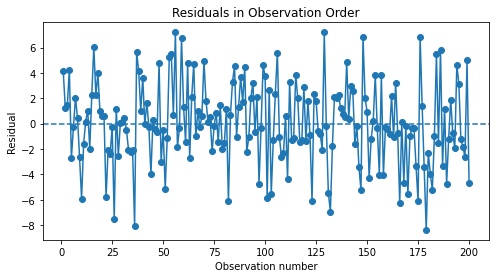

In [44]:
dw = durbin_watson(results.resid)
print(dw)

plt.figure(figsize=(8, 4))
plt.plot(results.resid, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Observation number")
plt.ylabel("Residual")
plt.title("Residuals in Observation Order")
plt.show()

#### Comment:

To assess the independence of the residuals, the Durbin–Watson statistic was calculated and the residuals were plotted in the order of the observations. The obtained DW statistic was 1.935, which is close to 2 and therefore indicates no substantial autocorrelation of the residuals. No clear trends or sequences of predominantly positive or negative residuals were observed in the plot. Therefore, the assumption of residual independence can be considered satisfied.

## 9. Multiple Linear Regression

In [45]:
Y = advertising["sales"]
X = advertising[["TV", "radio", "newspaper"]]


X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        07:29:08   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

#### Comment:

Compared with the previous model, which used only one explanatory variable, the use of multiple explanatory variables increased the adjusted R² to 0.896. This means that the model explains approximately 89.6% of the variability in the dependent variable, indicating a very good fit to the data.

The newspaper variable is statistically insignificant, suggesting that it does not have a statistically significant effect on the dependent variable. Therefore, in the next step, the newspaper variable was removed from the model due to its lack of statistical significance.

### 10. Assumptions of Multiple Linear Regression

#### a. Linearity

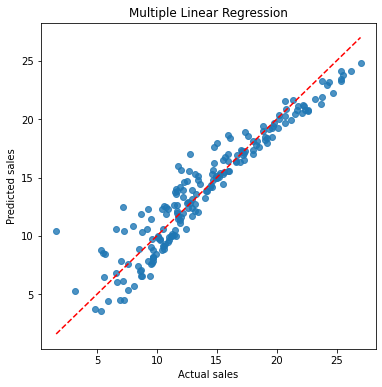

In [46]:
plt.figure(figsize=(6, 6))
plt.scatter(advertising["sales"], results.fittedvalues, alpha=0.8)
plt.plot(
    [advertising["sales"].min(), advertising["sales"].max()],
    [advertising["sales"].min(), advertising["sales"].max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Multiple Linear Regression")
plt.show()

#### Comment:

The points are concentrated around the y = x line, suggesting a good fit of the model to the data. At the same time, a slightly greater spread of points can be observed for higher sales values, indicating that the prediction accuracy decreases for higher values of the dependent variable. However, there is no clear systematic deviation from the line, suggesting that the model does not exhibit a significant systematic error.

#### b. Normality 

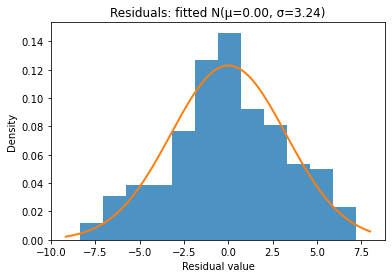

In [47]:
mu, sigma = stats.norm.fit(resid)

plt.hist(resid, bins=12, density=True, alpha=0.8)
xmin, xmax = plt.xlim()
x_line = np.linspace(xmin, xmax, 200)
plt.plot(x_line, stats.norm.pdf(x_line, mu, sigma), linewidth=2)

plt.title(f"Residuals: fitted N(μ={mu:.2f}, σ={sigma:.2f})")
plt.xlabel("Residual value")
plt.ylabel("Density")
plt.show()

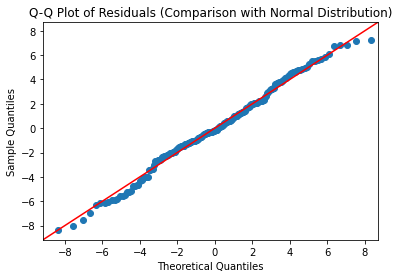

Shapiro-Wilk Test: stat=0.991, p-value=0.2133


In [48]:
qqplot(resid, loc=mu, scale=sigma, line="45")
plt.title("Q-Q Plot of Residuals (Comparison with Normal Distribution)")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk Test: stat={shapiro_stat:.3f}, p-value={shapiro_p:.4f}")

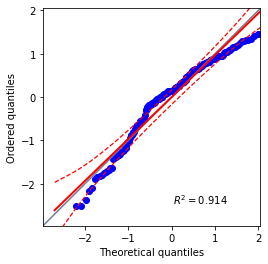

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))
pg.qqplot(results.resid, dist='norm', confidence=0.95)
plt.show()

#### Comment:

The Q-Q plot shows substantial deviations from the normal distribution, particularly at the tails of the plot. This suggests departures from normality in the tails as well as in the central part of the distribution. Overall, the plot suggests that the residuals are not normally distributed.


#### c. Homoskedasticity

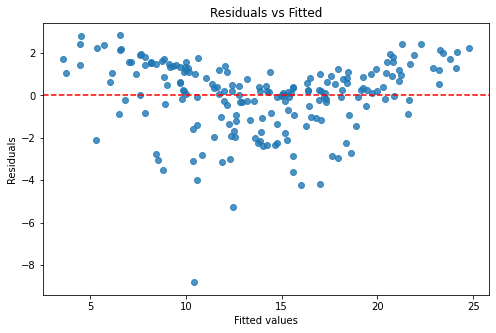

In [50]:
fitted = results.fittedvalues
resid = results.resid

plt.figure(figsize=(8,5))
plt.scatter(fitted, resid, alpha=0.8)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#### Comment:
The assumption of homoskedasticity is probably not satisfied. For larger fitted values, the model tends to produce larger residuals, indicating that the variance of the errors increases with the fitted values.

#### d. Checking for Multicollinearity (VIF)

                 TV     radio  newspaper
TV         1.000000  0.054809   0.056648
radio      0.054809  1.000000   0.354104
newspaper  0.056648  0.354104   1.000000


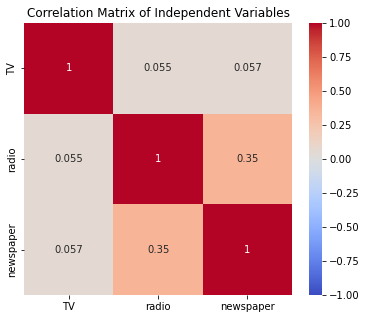

In [51]:
corr = advertising[["TV", "radio", "newspaper"]].corr()

print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Matrix of Independent Variables")
plt.show()

In [52]:
X_vif = advertising[["TV", "radio", "newspaper"]]

vif = pd.DataFrame()
vif["Zmienna"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

print(vif)

     Zmienna       VIF
0         TV  2.486772
1      radio  3.285462
2  newspaper  3.055245


#### Comment:
The assumption of no strong multicollinearity among the independent variables was assessed using the Variance Inflation Factor (VIF). The obtained VIF values were 2.49 for TV, 3.29 for radio, and 3.06 for newspaper. Since all VIF values are below 10, no substantial multicollinearity was identified among the explanatory variables. This indicates that the independent variables are not excessively correlated and can be included simultaneously in the multiple regression model.

## Removing the Newspaper variable and refitting the model

In [53]:
y = advertising["sales"]
x1 = advertising[["TV", "radio"]]


x1 = sm.add_constant(x1)

model = sm.OLS(y, x1)
results_tv_radio = model.fit()

print(results_tv_radio.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           4.83e-98
Time:                        07:29:14   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

### 11. Assumptions of Multiple Linear Regression

#### a. Linearity

Text(0.5, 1.0, 'Multiple Linear Regression')

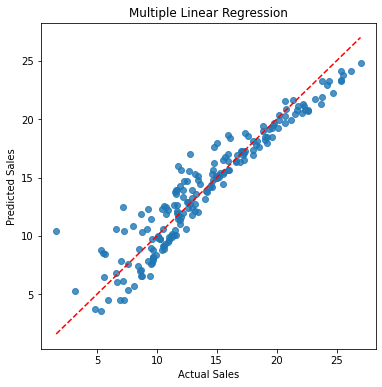

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(advertising["sales"], results_tv_radio.fittedvalues, alpha=0.8)
plt.plot(
    [advertising["sales"].min(), advertising["sales"].max()],
    [advertising["sales"].min(), advertising["sales"].max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Multiple Linear Regression")

#### Comment:

The model shows a better fit compared with the model using all explanatory variables. The plot shows greater dispersion of the points for lower values of the x variable. As sales increase, the points become closer to the predicted values, suggesting improved prediction accuracy at higher levels of sales.

#### b. Normaliy 

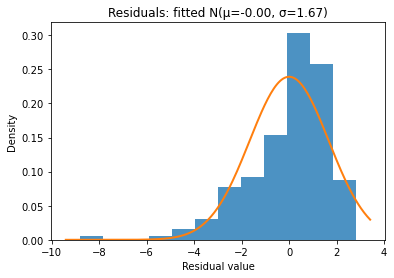

In [55]:
mu, sigma = stats.norm.fit(resid)

plt.hist(resid, bins=12, density=True, alpha=0.8)
xmin, xmax = plt.xlim()
x_line = np.linspace(xmin, xmax, 200)
plt.plot(x_line, stats.norm.pdf(x_line, mu, sigma), linewidth=2)

plt.title(f"Residuals: fitted N(μ={mu:.2f}, σ={sigma:.2f})")
plt.xlabel("Residual value")
plt.ylabel("Density")
plt.show()

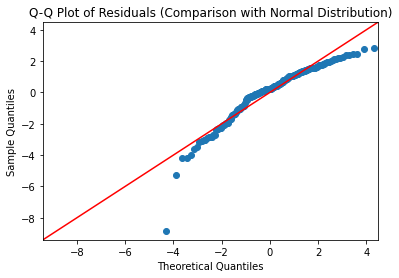

Test Shapiro–Wilka: stat=0.918, p-value=0.0000


In [56]:
qqplot(resid, loc=mu, scale=sigma, line="45")
plt.title("Q-Q Plot of Residuals (Comparison with Normal Distribution)")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Test Shapiro–Wilka: stat={shapiro_stat:.3f}, p-value={shapiro_p:.4f}")

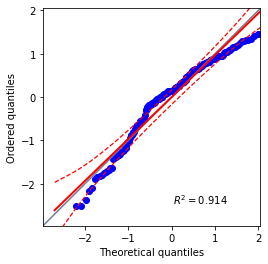

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))
pg.qqplot(results.resid, dist='norm', confidence=0.95)
plt.show()

#### Comment:

The Q-Q plot shows that the points largely follow the reference line, suggesting that the distribution of the residuals is close to normal. However, some deviations from the line are visible, particularly in the extreme parts of the distribution (the tails). The value of R² = 0.914 indicates a relatively good, but not perfect, fit of the points to the theoretical line.

The distribution of the residuals can therefore be considered approximately normal, although there are minor deviations from normality, especially in the tails of the distribution.

#### c. Homoskedasticity

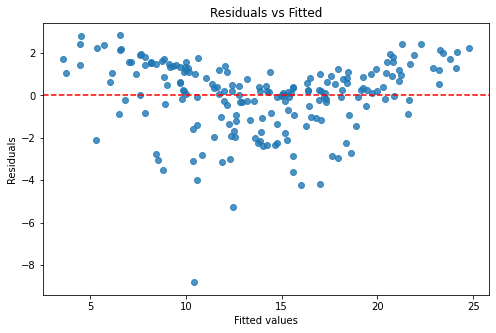

In [58]:
fitted = results.fittedvalues
resid = results.resid

plt.figure(figsize=(8,5))
plt.scatter(fitted, resid, alpha=0.8)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#### Comment:

The points are relatively evenly distributed around the zero line, ranging from approximately −2 to 2. There is slightly greater dispersion in the central part of the plot; however, the points do not form a clear pattern or funnel shape. This suggests that the assumption of homoskedasticity is reasonably well satisfied.

#### d. Checking for Multicollinearity (VIF)

             TV     radio
TV     1.000000  0.054809
radio  0.054809  1.000000


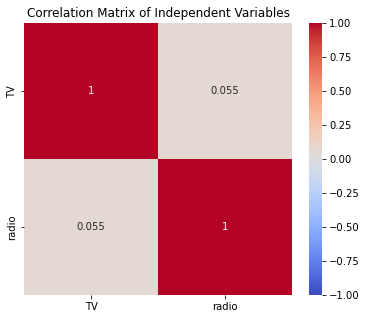

In [59]:
corr = advertising[["TV", "radio"]].corr()

print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Independent Variables")
plt.show()

In [60]:
X_vif = advertising[["TV", "radio"]]

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

print(vif)

  Variable       VIF
0       TV  2.238085
1    radio  2.238085


#### Comment:

The VIF values for both explanatory variables, TV and radio, are approximately 2.24. This indicates a slight relationship between the variables, but it does not suggest a significant multicollinearity problem. Both VIF values are well below the commonly used threshold of 5 (and also 10). Therefore, there is no evidence of excessive multicollinearity between the TV and radio variables.